# Clean Microsoft Buildings Data

In [1]:
import os
import sys

import geopandas as gpd
import pandas as pd

sys.path.append("../utils")

import config

### Import Microsoft Buildings dataset

In [2]:
# Import Microsoft Buildings dataset
buildings_path = os.path.join(
    config.data_dir, "microsoft_buildings", "California.geojson"
)
buildings_ca = gpd.read_file(buildings_path)

### Subset buildings data to SB County

In [5]:
# Import SB county shape
sb_county = gpd.read_file(
    os.path.join(config.data_dir, "ca_counties", "sb_county_boundary.shp")
).to_crs(config.albers_crs)

# Reproject the buildings data to match the county data's CRS
buildings = buildings_ca.to_crs(config.albers_crs)

# Then perform the spatial join
buildings = buildings.sjoin(sb_county, predicate="intersects")

<Axes: >

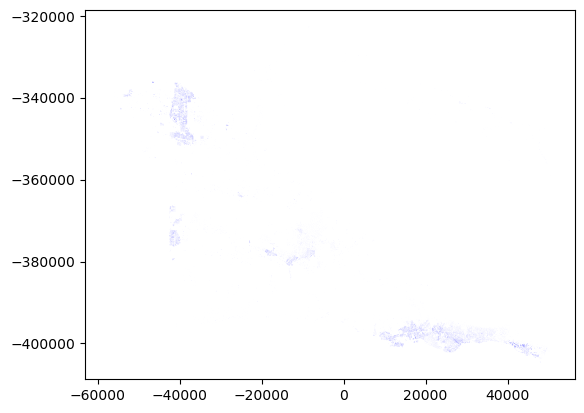

In [6]:
# Drop the extra column and plot
buildings = buildings.drop(columns=["index_right"])
buildings.plot(color="blue", alpha=0.5)

### Save subsetted buildings to file

located in `data/microsoft_buildings/sb_buildings.geojson`

In [7]:
sb_buildings_path = os.path.join(
    config.data_dir, "microsoft_buildings", "sb_buildings.geojson"
)

buildings.to_file(sb_buildings_path, driver="GeoJSON")